# Cassava Leaf Disease Classification
**Berkin Ozturk** | Deep Learning with PyTorch, Capstone Project

Classify photos of cassava leaves into 5 categories (4 diseases + healthy), then hand the
model's output to Claude through the Anthropic API so a farmer gets a plain-language
explanation instead of a bare label. Everything is wrapped in a Gradio interface at the end.

**Dataset:** iCassava 2019 (Mwebaze et al.), 9,430 labelled field photos, public download,
not used in any class or homework.

**Classes:** `cbb` bacterial blight, `cbsd` brown streak disease, `cgm` green mite damage,
`cmd` mosaic disease, `healthy`.

**Runtime:** set Colab to GPU (Runtime > Change runtime type > T4 GPU) before running.

## 1. Setup

In [1]:
!pip install -q anthropic gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.6 MB/s eta 0:00:00


In [2]:
import os, json, time, random, zipfile, urllib.request, copy
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, accuracy_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE.type != "cuda":
    print("No GPU found. Training will be slow. Runtime > Change runtime type > T4 GPU.")

torch 2.11.0+cu128 | device: cuda


## 2. Data

The zip is hosted publicly by the dataset authors, so there is no Kaggle login step.
It already ships as train / validation / test folders in ImageFolder layout, which means
the split is fixed and reproducible instead of something I shuffled myself.

In [3]:
URL = "https://storage.googleapis.com/emcassavadata/cassavaleafdata.zip"
ZIP = Path("cassavaleafdata.zip")
ROOT = Path("data")

if not ROOT.exists():
    if not ZIP.exists():
        print("downloading, this takes a couple of minutes...")
        urllib.request.urlretrieve(URL, ZIP)
    with zipfile.ZipFile(ZIP) as z:
        z.extractall(ROOT)
    print("extracted")

# The zip nests everything one level down, and the folder name has changed between
# mirrors before, so find the split folders instead of hardcoding the path.
def find_split(name):
    hits = [p for p in ROOT.rglob(name) if p.is_dir() and any(c.is_dir() for c in p.iterdir())]
    if not hits:
        raise FileNotFoundError(f"could not find a '{name}' folder under {ROOT}")
    return sorted(hits, key=lambda p: len(p.parts))[0]

TRAIN_DIR = find_split("train")
VAL_DIR   = find_split("validation")
TEST_DIR  = find_split("test")
for d in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    print(d, "->", sorted(p.name for p in d.iterdir() if p.is_dir()))

downloading, this takes a couple of minutes...
extracted
data/cassavaleafdata/train -> ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
data/cassavaleafdata/validation -> ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
data/cassavaleafdata/test -> ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']


In [4]:
# Some images in this dataset are truncated and PIL refuses to open them by default.
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

counts = {}
for split, d in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    counts[split] = {c.name: len(list(c.glob("*.jpg"))) for c in sorted(d.iterdir()) if c.is_dir()}
    print(split, counts[split], "total", sum(counts[split].values()))

train {'cbb': 466, 'cbsd': 1443, 'cgm': 773, 'cmd': 2658, 'healthy': 316} total 5656
val {'cbb': 156, 'cbsd': 482, 'cgm': 258, 'cmd': 887, 'healthy': 106} total 1889
test {'cbb': 155, 'cbsd': 481, 'cgm': 258, 'cmd': 886, 'healthy': 105} total 1885


The class counts are lopsided. CMD has roughly ten times the images of healthy. That matters
for two reasons: accuracy alone will look good just from predicting CMD, and the rare classes
will get ignored during training unless I do something. I handle it with class-weighted loss
and report per-class F1 rather than only accuracy.

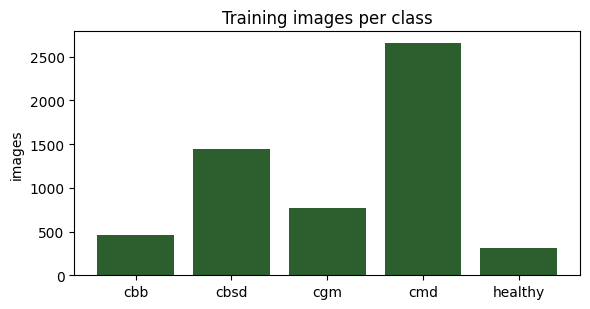

In [5]:
FIG = Path("figures"); FIG.mkdir(exist_ok=True)   # every chart gets saved here too

plt.figure(figsize=(6,3.2))
ks = list(counts["train"].keys())
plt.bar(ks, [counts["train"][k] for k in ks], color="#2C5F2D")
plt.title("Training images per class"); plt.ylabel("images")
plt.tight_layout(); plt.savefig(FIG/"class_distribution.png", dpi=150); plt.show()

### Preprocessing and augmentation

These are field photos taken on phones: uneven lighting, leaves at every angle, cluttered
backgrounds. So the augmentation leans on geometry and colour jitter rather than anything exotic.
Normalization uses ImageNet statistics because the transfer model expects that distribution.

In [6]:
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.1)),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  eval_tf)

CLASSES = train_ds.classes
NUM_CLASSES = len(CLASSES)
assert val_ds.classes == CLASSES == test_ds.classes, "class order differs between splits"
print(CLASSES, len(train_ds), len(val_ds), len(test_ds))

['cbb', 'cbsd', 'cgm', 'cmd', 'healthy'] 5656 1889 1885


In [7]:
BATCH_SIZE = 32
NUM_WORKERS = 2

def make_loaders(batch_size=BATCH_SIZE):
    tl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    vl = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)
    sl = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)
    return tl, vl, sl

train_loader, val_loader, test_loader = make_loaders()

# Inverse-frequency weights so the rare classes actually contribute to the gradient.
freq = Counter(train_ds.targets)
w = torch.tensor([len(train_ds) / (NUM_CLASSES * freq[i]) for i in range(NUM_CLASSES)],
                 dtype=torch.float, device=DEVICE)
print({CLASSES[i]: round(w[i].item(), 2) for i in range(NUM_CLASSES)})

{'cbb': 2.43, 'cbsd': 0.78, 'cgm': 1.46, 'cmd': 0.43, 'healthy': 3.58}


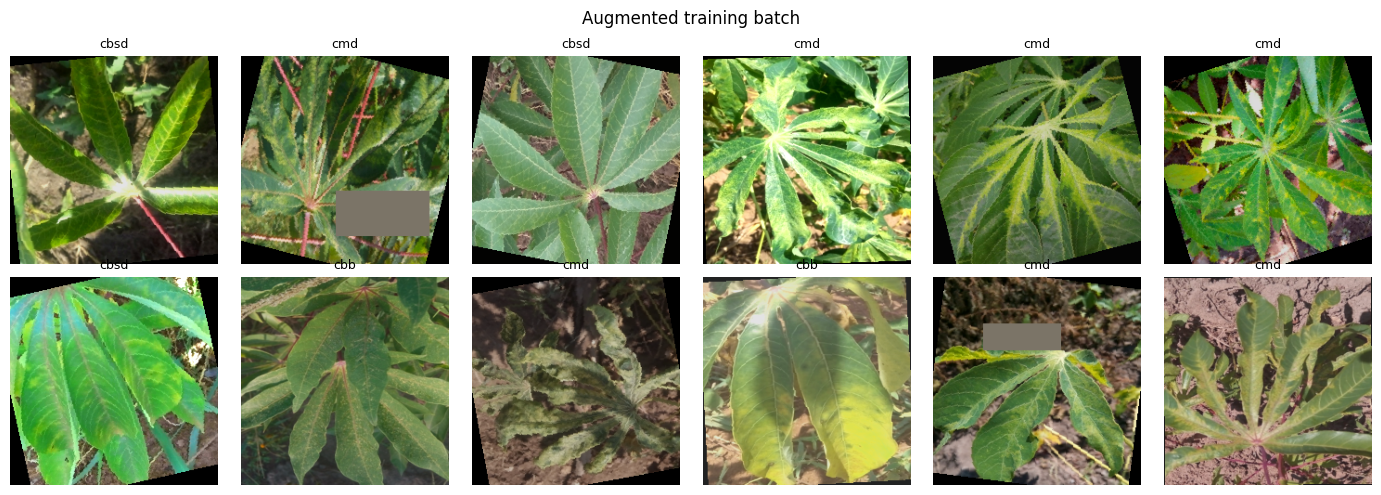

In [8]:
def denorm(t):
    return (t.permute(1,2,0).cpu().numpy() * np.array(STD) + np.array(MEAN)).clip(0,1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, im, lb in zip(axes.ravel(), imgs, labels):
    ax.imshow(denorm(im)); ax.set_title(CLASSES[lb], fontsize=9); ax.axis("off")
plt.suptitle("Augmented training batch"); plt.tight_layout()
plt.savefig(FIG/"augmented_batch.png", dpi=130); plt.show()

## 3. Models

Two of them, so there is something to compare.

**SmallCNN** is written from scratch: four conv blocks, batch norm, dropout. It is the honest
baseline that shows what the data gives you with no outside help.

**ResNet18** starts from ImageNet weights with a new 5-way head. Cassava has under 6k training
images, which is not enough to learn good low-level filters from nothing, so transfer learning
should win by a wide margin. That gap is the interesting result, not the final accuracy number.

In [9]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3,32), block(32,64), block(64,128), block(128,256))
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.head(self.features(x))


def build_resnet18(num_classes, freeze_backbone=False):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in m.parameters():
            p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, num_classes)   # new head, always trainable
    return m

print(sum(p.numel() for p in SmallCNN(5).parameters())/1e6, "M params (SmallCNN)")
print(sum(p.numel() for p in build_resnet18(5).parameters())/1e6, "M params (ResNet18)")

1.175461 M params (SmallCNN)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 87.9MB/s]


11.179077 M params (ResNet18)


## 4. Training loop

Early stopping on validation macro F1 rather than validation accuracy. With this much class
imbalance, accuracy can climb while the rare classes get worse, and macro F1 catches that.

In [10]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train(train)
    total_loss, preds, gts = 0.0, [], []
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(train):
            with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type=="cuda")):
                out = model(x)
                loss = criterion(out, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * x.size(0)
        preds.append(out.argmax(1).detach().cpu()); gts.append(y.cpu())
    preds = torch.cat(preds).numpy(); gts = torch.cat(gts).numpy()
    _, _, f1, _ = precision_recall_fscore_support(gts, preds, average="macro", zero_division=0)
    return total_loss/len(loader.dataset), accuracy_score(gts, preds), f1


def train_model(model, train_loader, val_loader, epochs=15, lr=3e-4, weight_decay=1e-4,
                patience=4, label="model", class_weights=None, verbose=True):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_loader))
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type=="cuda"))

    hist = {k: [] for k in ["train_loss","train_acc","train_f1","val_loss","val_acc","val_f1"]}
    best_f1, best_state, bad_epochs = -1.0, None, 0

    for ep in range(1, epochs+1):
        t0 = time.time()
        model.train()
        tot, preds, gts = 0.0, [], []
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type=="cuda")):
                out = model(x); loss = criterion(out, y)
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update(); sched.step()
            tot += loss.item()*x.size(0)
            preds.append(out.argmax(1).detach().cpu()); gts.append(y.cpu())
        preds = torch.cat(preds).numpy(); gts = torch.cat(gts).numpy()
        tr_loss = tot/ (len(train_loader)*train_loader.batch_size)
        tr_acc = accuracy_score(gts, preds)
        _,_,tr_f1,_ = precision_recall_fscore_support(gts, preds, average="macro", zero_division=0)

        va_loss, va_acc, va_f1 = run_epoch(model, val_loader, criterion)

        for k, v in zip(hist, [tr_loss,tr_acc,tr_f1,va_loss,va_acc,va_f1]):
            hist[k].append(v)
        if verbose:
            print(f"[{label}] ep{ep:02d} "
                  f"train loss {tr_loss:.3f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | "
                  f"val loss {va_loss:.3f} acc {va_acc:.3f} f1 {va_f1:.3f} "
                  f"({time.time()-t0:.0f}s)")

        if va_f1 > best_f1 + 1e-4:
            best_f1, bad_epochs = va_f1, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{label}] early stop at epoch {ep}, best val f1 {best_f1:.3f}")
                break

    model.load_state_dict(best_state)   # roll back to the best epoch, not the last one
    return model, hist, best_f1

### 4a. Baseline: SmallCNN from scratch

In [11]:
cnn = SmallCNN(NUM_CLASSES)
cnn, cnn_hist, cnn_f1 = train_model(cnn, train_loader, val_loader, epochs=15, lr=1e-3,
                                    label="smallcnn", class_weights=w)

[smallcnn] ep01 train loss 1.625 acc 0.317 f1 0.268 | val loss 1.595 acc 0.361 f1 0.300 (91s)
[smallcnn] ep02 train loss 1.549 acc 0.384 f1 0.307 | val loss 1.509 acc 0.488 f1 0.323 (85s)
[smallcnn] ep03 train loss 1.554 acc 0.374 f1 0.296 | val loss 1.546 acc 0.401 f1 0.265 (85s)
[smallcnn] ep04 train loss 1.520 acc 0.396 f1 0.322 | val loss 1.568 acc 0.408 f1 0.334 (85s)
[smallcnn] ep05 train loss 1.499 acc 0.418 f1 0.343 | val loss 1.586 acc 0.414 f1 0.356 (84s)
[smallcnn] ep06 train loss 1.470 acc 0.439 f1 0.359 | val loss 1.484 acc 0.481 f1 0.424 (86s)
[smallcnn] ep07 train loss 1.413 acc 0.477 f1 0.396 | val loss 1.547 acc 0.484 f1 0.364 (85s)
[smallcnn] ep08 train loss 1.360 acc 0.517 f1 0.434 | val loss 1.529 acc 0.489 f1 0.423 (84s)
[smallcnn] ep09 train loss 1.277 acc 0.568 f1 0.486 | val loss 1.351 acc 0.598 f1 0.530 (85s)
[smallcnn] ep10 train loss 1.232 acc 0.594 f1 0.514 | val loss 1.243 acc 0.675 f1 0.604 (86s)
[smallcnn] ep11 train loss 1.200 acc 0.617 f1 0.538 | val lo

### 4b. Transfer learning: ResNet18

In [12]:
rn = build_resnet18(NUM_CLASSES)
rn, rn_hist, rn_f1 = train_model(rn, train_loader, val_loader, epochs=15, lr=3e-4,
                                 label="resnet18", class_weights=w)

[resnet18] ep01 train loss 1.370 acc 0.419 f1 0.387 | val loss 1.217 acc 0.654 f1 0.589 (82s)
[resnet18] ep02 train loss 1.027 acc 0.698 f1 0.629 | val loss 1.158 acc 0.710 f1 0.649 (82s)
[resnet18] ep03 train loss 0.995 acc 0.724 f1 0.653 | val loss 1.100 acc 0.762 f1 0.682 (83s)
[resnet18] ep04 train loss 0.958 acc 0.746 f1 0.680 | val loss 0.986 acc 0.801 f1 0.734 (81s)
[resnet18] ep05 train loss 0.911 acc 0.770 f1 0.704 | val loss 1.052 acc 0.754 f1 0.675 (82s)
[resnet18] ep06 train loss 0.862 acc 0.788 f1 0.722 | val loss 0.909 acc 0.848 f1 0.790 (82s)
[resnet18] ep07 train loss 0.831 acc 0.800 f1 0.739 | val loss 0.969 acc 0.815 f1 0.750 (82s)
[resnet18] ep08 train loss 0.769 acc 0.821 f1 0.766 | val loss 1.003 acc 0.795 f1 0.726 (85s)
[resnet18] ep09 train loss 0.757 acc 0.832 f1 0.775 | val loss 1.077 acc 0.755 f1 0.682 (83s)
[resnet18] ep10 train loss 0.707 acc 0.848 f1 0.797 | val loss 0.964 acc 0.814 f1 0.749 (83s)
[resnet18] early stop at epoch 10, best val f1 0.790


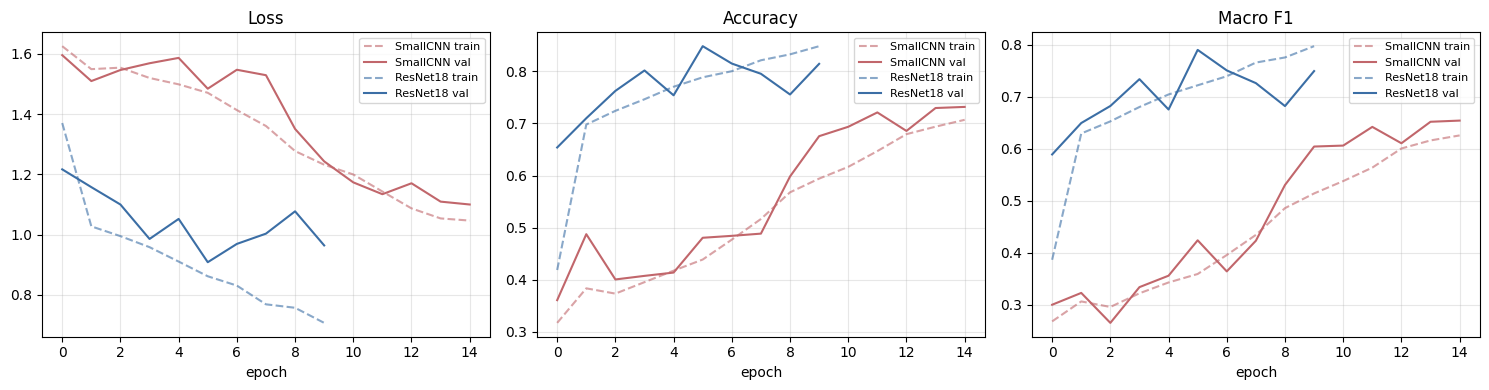

best val macro F1  SmallCNN 0.654   ResNet18 0.790


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss","acc","f1"], ["Loss","Accuracy","Macro F1"]):
    for h, name, c in [(cnn_hist,"SmallCNN","#c1666b"), (rn_hist,"ResNet18","#3b6ea5")]:
        ax.plot(h[f"train_{key}"], "--", color=c, alpha=.6, label=f"{name} train")
        ax.plot(h[f"val_{key}"], "-", color=c, label=f"{name} val")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG/"training_curves.png", dpi=150); plt.show()
print(f"best val macro F1  SmallCNN {cnn_f1:.3f}   ResNet18 {rn_f1:.3f}")

## 5. Hyperparameter tuning

Short runs (6 epochs each) over learning rate and batch size on the ResNet. Enough to rank the
settings without burning the Colab session. The winner gets retrained properly below.

In [14]:
SWEEP = [
    dict(lr=1e-3, batch_size=32, weight_decay=1e-4),
    dict(lr=3e-4, batch_size=32, weight_decay=1e-4),
    dict(lr=1e-4, batch_size=32, weight_decay=1e-4),
    dict(lr=3e-4, batch_size=64, weight_decay=1e-4),
    dict(lr=3e-4, batch_size=32, weight_decay=1e-2),
]

sweep_results = []
for cfg in SWEEP:
    tl, vl, _ = make_loaders(cfg["batch_size"])
    m = build_resnet18(NUM_CLASSES)
    _, _, f1 = train_model(m, tl, vl, epochs=6, lr=cfg["lr"],
                           weight_decay=cfg["weight_decay"], patience=6,
                           label=f"lr{cfg['lr']}_bs{cfg['batch_size']}",
                           class_weights=w, verbose=False)
    sweep_results.append({**cfg, "val_macro_f1": round(f1, 4)})
    print(sweep_results[-1])
    del m; torch.cuda.empty_cache()

import pandas as pd
sweep_df = pd.DataFrame(sweep_results).sort_values("val_macro_f1", ascending=False)
sweep_df

{'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'val_macro_f1': 0.7589}
{'lr': 0.0003, 'batch_size': 32, 'weight_decay': 0.0001, 'val_macro_f1': 0.7609}
{'lr': 0.0001, 'batch_size': 32, 'weight_decay': 0.0001, 'val_macro_f1': 0.7251}
{'lr': 0.0003, 'batch_size': 64, 'weight_decay': 0.0001, 'val_macro_f1': 0.77}
{'lr': 0.0003, 'batch_size': 32, 'weight_decay': 0.01, 'val_macro_f1': 0.7467}


,lr,batch_size,weight_decay,val_macro_f1
3,0.0003,64,0.0001,0.7700
1,0.0003,32,0.0001,0.7609
0,0.0010,32,0.0001,0.7589
4,0.0003,32,0.0100,0.7467
2,0.0001,32,0.0001,0.7251


In [15]:
best_cfg = sweep_df.iloc[0].to_dict()
print("best config:", best_cfg)

tl, vl, _ = make_loaders(int(best_cfg["batch_size"]))
final = build_resnet18(NUM_CLASSES)
final, final_hist, final_f1 = train_model(
    final, tl, vl, epochs=25, lr=float(best_cfg["lr"]),
    weight_decay=float(best_cfg["weight_decay"]), patience=5,
    label="final", class_weights=w)

best config: {'lr': 0.0003, 'batch_size': 64.0, 'weight_decay': 0.0001, 'val_macro_f1': 0.77}
[final] ep01 train loss 1.442 acc 0.381 f1 0.352 | val loss 1.305 acc 0.581 f1 0.515 (81s)
[final] ep02 train loss 1.082 acc 0.657 f1 0.587 | val loss 1.214 acc 0.661 f1 0.604 (80s)
[final] ep03 train loss 0.948 acc 0.731 f1 0.665 | val loss 1.130 acc 0.697 f1 0.642 (81s)
[final] ep04 train loss 0.896 acc 0.763 f1 0.696 | val loss 1.181 acc 0.709 f1 0.642 (80s)
[final] ep05 train loss 0.876 acc 0.776 f1 0.711 | val loss 1.213 acc 0.675 f1 0.647 (79s)
[final] ep06 train loss 0.841 acc 0.779 f1 0.718 | val loss 1.120 acc 0.740 f1 0.679 (80s)
[final] ep07 train loss 0.837 acc 0.792 f1 0.730 | val loss 1.029 acc 0.799 f1 0.734 (81s)
[final] ep08 train loss 0.792 acc 0.808 f1 0.746 | val loss 1.051 acc 0.754 f1 0.680 (81s)
[final] ep09 train loss 0.758 acc 0.824 f1 0.772 | val loss 1.098 acc 0.754 f1 0.693 (81s)
[final] ep10 train loss 0.728 acc 0.835 f1 0.783 | val loss 0.975 acc 0.804 f1 0.742 (8

## 6. Evaluation

Validation first, since that is what I tuned against. The test set is touched once, at the end.


===== ResNet18 (final) on validation =====
accuracy 0.8682
              precision    recall  f1-score   support

         cbb      0.667     0.731     0.697       156
        cbsd      0.887     0.813     0.848       482
         cgm      0.799     0.880     0.838       258
         cmd      0.953     0.919     0.936       887
     healthy      0.672     0.868     0.757       106

    accuracy                          0.868      1889
   macro avg      0.796     0.842     0.815      1889
weighted avg      0.876     0.868     0.870      1889



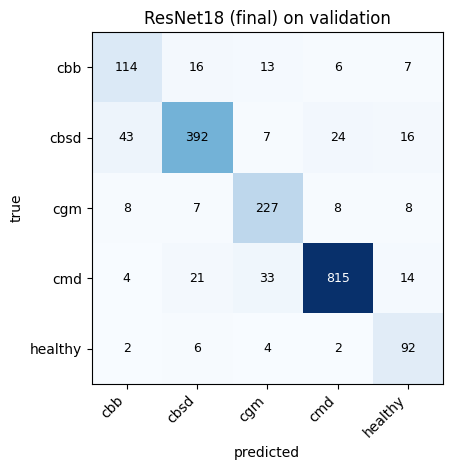

In [16]:
@torch.no_grad()
def predict(model, loader):
    model.eval().to(DEVICE)
    probs, gts = [], []
    for x, y in loader:
        out = model(x.to(DEVICE))
        probs.append(torch.softmax(out.float(), 1).cpu()); gts.append(y)
    return torch.cat(probs).numpy(), torch.cat(gts).numpy()


def report(model, loader, title, savename=None):
    p, y = predict(model, loader)
    pred = p.argmax(1)
    print(f"\n===== {title} =====")
    print(f"accuracy {accuracy_score(y, pred):.4f}")
    print(classification_report(y, pred, target_names=CLASSES, digits=3, zero_division=0))
    cm = confusion_matrix(y, pred)
    fig, ax = plt.subplots(figsize=(5.5,4.8))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASSES)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    plt.tight_layout()
    if savename:
        plt.savefig(FIG/savename, dpi=150)
    plt.show()
    return p, y, pred

val_p, val_y, val_pred = report(final, vl, "ResNet18 (final) on validation",
                                "confusion_val.png")

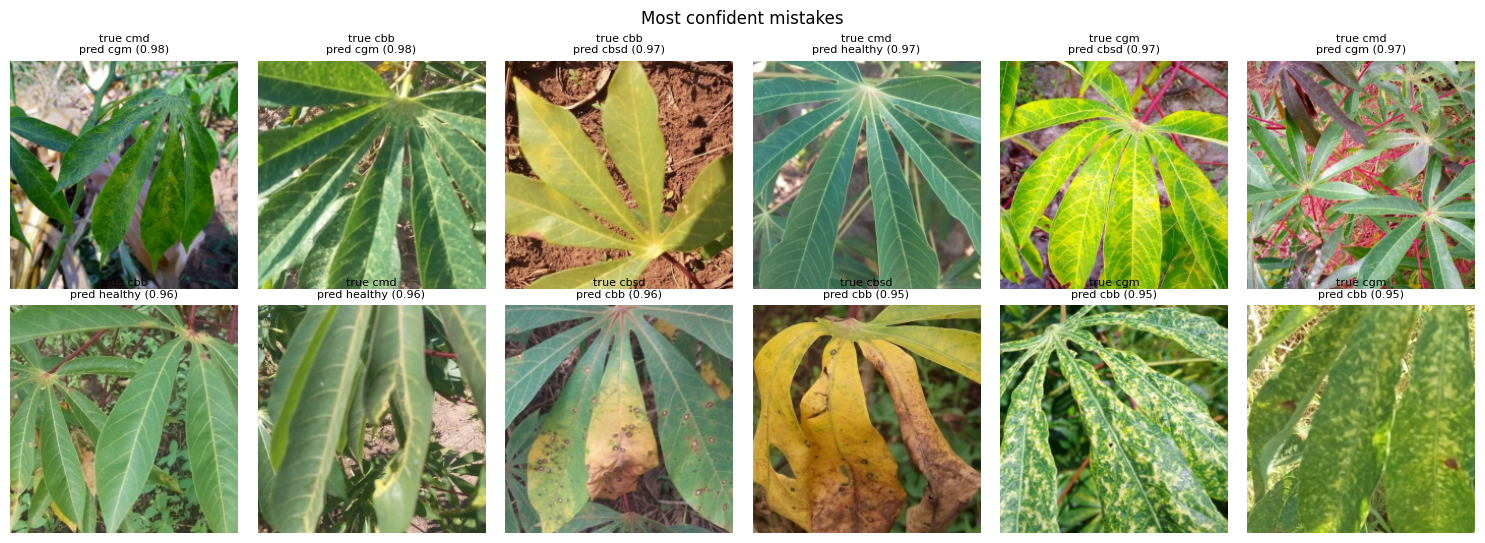

In [17]:
# Where it goes wrong, sorted by how confident it was while being wrong.
wrong = np.where(val_pred != val_y)[0]
conf = val_p[wrong, val_pred[wrong]]
order = wrong[np.argsort(-conf)][:12]

fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for ax, idx in zip(axes.ravel(), order):
    img, _ = val_ds[idx]
    ax.imshow(denorm(img)); ax.axis("off")
    ax.set_title(f"true {CLASSES[val_y[idx]]}\npred {CLASSES[val_pred[idx]]} "
                 f"({val_p[idx, val_pred[idx]]:.2f})", fontsize=8)
plt.suptitle("Most confident mistakes"); plt.tight_layout()
plt.savefig(FIG/"mistakes.png", dpi=130); plt.show()

## 7. Final test

One pass, no tuning after this.


===== SmallCNN on test =====
accuracy 0.7469
              precision    recall  f1-score   support

         cbb      0.486     0.548     0.515       155
        cbsd      0.837     0.642     0.727       481
         cgm      0.718     0.779     0.747       258
         cmd      0.926     0.810     0.865       886
     healthy      0.332     0.905     0.486       105

    accuracy                          0.747      1885
   macro avg      0.660     0.737     0.668      1885
weighted avg      0.806     0.747     0.764      1885



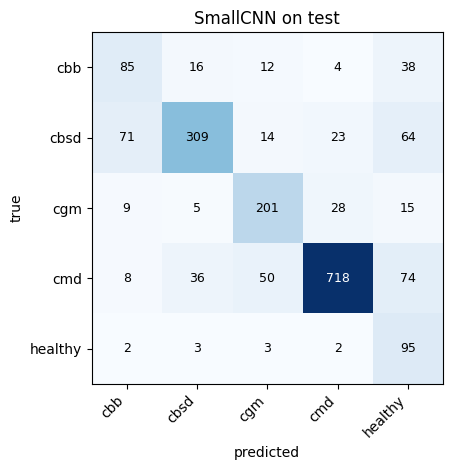


===== ResNet18 (final) on test =====
accuracy 0.8653
              precision    recall  f1-score   support

         cbb      0.659     0.774     0.712       155
        cbsd      0.901     0.813     0.855       481
         cgm      0.795     0.857     0.825       258
         cmd      0.947     0.910     0.928       886
     healthy      0.664     0.886     0.759       105

    accuracy                          0.865      1885
   macro avg      0.793     0.848     0.816      1885
weighted avg      0.875     0.865     0.868      1885



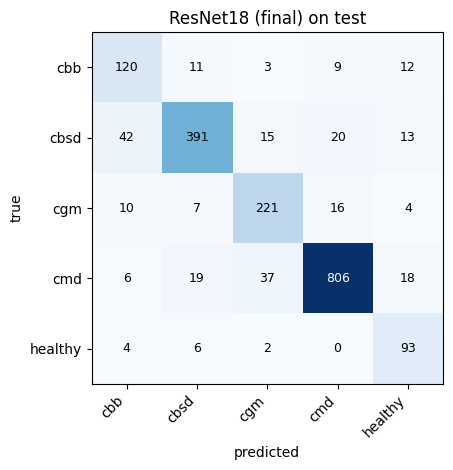

{
  "classes": [
    "cbb",
    "cbsd",
    "cgm",
    "cmd",
    "healthy"
  ],
  "best_config": {
    "lr": 0.0003,
    "batch_size": 64.0,
    "weight_decay": 0.0001
  },
  "sweep": [
    {
      "lr": 0.001,
      "batch_size": 32,
      "weight_decay": 0.0001,
      "val_macro_f1": 0.7589
    },
    {
      "lr": 0.0003,
      "batch_size": 32,
      "weight_decay": 0.0001,
      "val_macro_f1": 0.7609
    },
    {
      "lr": 0.0001,
      "batch_size": 32,
      "weight_decay": 0.0001,
      "val_macro_f1": 0.7251
    },
    {
      "lr": 0.0003,
      "batch_size": 64,
      "weight_decay": 0.0001,
      "val_macro_f1": 0.77
    },
    {
      "lr": 0.0003,
      "batch_size": 32,
      "weight_decay": 0.01,
      "val_macro_f1": 0.7467
    }
  ],
  "smallcnn_test_acc": 0.7469496021220159,
  "smallcnn_test_macro_precision": 0.6599178495252452,
  "smallcnn_test_macro_recall": 0.7370028317135862,
  "smallcnn_test_macro_f1": 0.6679790345007766,
  "resnet18_test_acc": 0.86525198938

In [18]:
cnn_test_p, cnn_test_y, _ = report(cnn, test_loader, "SmallCNN on test",
                                   "confusion_test_smallcnn.png")
test_p, test_y, test_pred = report(final, test_loader, "ResNet18 (final) on test",
                                   "confusion_test_resnet18.png")

prec, rec, f1, _ = precision_recall_fscore_support(test_y, test_pred, average="macro",
                                                   zero_division=0)
cprec, crec, cf1, _ = precision_recall_fscore_support(cnn_test_y, cnn_test_p.argmax(1),
                                                      average="macro", zero_division=0)
results = {
    "classes": CLASSES,
    "best_config": {k: best_cfg[k] for k in ["lr","batch_size","weight_decay"]},
    "sweep": sweep_results,
    "smallcnn_test_acc": float(accuracy_score(cnn_test_y, cnn_test_p.argmax(1))),
    "smallcnn_test_macro_precision": float(cprec),
    "smallcnn_test_macro_recall": float(crec),
    "smallcnn_test_macro_f1": float(cf1),
    "resnet18_test_acc": float(accuracy_score(test_y, test_pred)),
    "resnet18_test_macro_precision": float(prec),
    "resnet18_test_macro_recall": float(rec),
    "resnet18_test_macro_f1": float(f1),
    "per_class": classification_report(test_y, test_pred, target_names=CLASSES,
                                       output_dict=True, zero_division=0),
    "test_confusion_matrix": confusion_matrix(test_y, test_pred).tolist(),
}
Path("results.json").write_text(json.dumps(results, indent=2, default=float))
print(json.dumps({k: v for k, v in results.items() if k != "per_class"}, indent=2, default=float))

In [19]:
torch.save({"state_dict": final.state_dict(), "classes": CLASSES,
            "arch": "resnet18", "img_size": IMG_SIZE},
           "cassava_resnet18.pt")
print("saved cassava_resnet18.pt", round(os.path.getsize("cassava_resnet18.pt")/1e6, 1), "MB")

saved cassava_resnet18.pt 44.8 MB


## 8. Passing the model output to Claude

This is the part the whiteboard asked for. The classifier returns a label and a probability
distribution, which is not much use to someone standing in a field. So the top predictions get
sent to Claude, which turns them into a short set of next steps.

Two things I made sure of: the prompt carries the actual probabilities so the model can hedge
when the classifier is unsure, and the API key comes from Colab Secrets, not from a string in
the notebook.



In [20]:
from anthropic import Anthropic

try:
    from google.colab import userdata
    API_KEY = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    API_KEY = os.environ.get("ANTHROPIC_API_KEY", "")

client = Anthropic(api_key=API_KEY)
# If this model string 404s, run `[m.id for m in client.models.list()]` and pick a current one.
LLM_MODEL = "claude-sonnet-4-6"

DISEASE_NAMES = {
    "cbb": "Cassava Bacterial Blight",
    "cbsd": "Cassava Brown Streak Disease",
    "cgm": "Cassava Green Mite damage",
    "cmd": "Cassava Mosaic Disease",
    "healthy": "Healthy",
}

def explain(top):
    # top is a list of (class_name, probability) tuples, highest probability first.
    lines = "\n".join(f"- {DISEASE_NAMES.get(c, c)}: {p:.1%}" for c, p in top)
    prompt = (
        "An image classifier looked at a cassava leaf photo and produced these probabilities:\n"
        f"{lines}\n\n"
        "You are an agricultural extension officer talking to a smallholder farmer in Uganda. "
        "In under 150 words: say what this most likely is, what to do in the next week, and "
        "whether the confidence is low enough that a human should check. Plain language, no jargon."
    )
    msg = client.messages.create(model=LLM_MODEL, max_tokens=400,
                                 messages=[{"role": "user", "content": prompt}])
    return msg.content[0].text

In [21]:
# Smoke test on one real validation image.
i = int(np.argmax(val_p.max(1)))
top3 = sorted(zip(CLASSES, val_p[i]), key=lambda t: -t[1])[:3]
print("true:", CLASSES[val_y[i]], "| top3:", [(c, round(float(p),3)) for c, p in top3])
print()
print(explain([(c, float(p)) for c, p in top3]))

true: healthy | top3: [('healthy', 0.999), ('cbb', 0.0), ('cmd', 0.0)]

## Your Cassava Looks Healthy! 🌿

**Good news** – the computer is 99.9% sure your cassava leaf is **healthy**. That is about as confident as this tool gets.

**What to do this week:**
- Keep doing what you are doing – your crop management is working
- Walk through your field and quickly check a few more plants, especially any that look different or yellowing
- Make sure your soil stays moist but not waterlogged during this growth stage

**Do you need a human expert to check?**

**No, not urgently.** At 99.9% confidence, this result is very reliable. However, if *you* notice anything unusual with your own eyes – spotted leaves, wilting, or sticky stems – then yes, contact your local agricultural officer. Always trust what you see in the field alongside what the computer says.

Your crop is doing well – keep it up! 👍


## 9. Gradio interface

Upload a leaf photo, get the class probabilities and the written advice side by side.
`share=True` gives a public link that lasts 72 hours, which is handy for the demo.

In [31]:
# Pull one brown streak test image out to my machine so I can try the interface
# below on a photo the model has never seen during training.
import glob
from google.colab import files
files.download(sorted(glob.glob(str(TEST_DIR/"cbsd"/"*.jpg")))[0])


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import gradio as gr

final.eval().to(DEVICE)

def classify(image):
    if image is None:
        return {}, "Upload a leaf photo first."
    x = eval_tf(image.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(final(x).float(), 1)[0].cpu().numpy()
    scores = {DISEASE_NAMES.get(c, c): float(p) for c, p in zip(CLASSES, probs)}
    top = sorted(zip(CLASSES, probs), key=lambda t: -t[1])[:3]
    try:
        advice = explain([(c, float(p)) for c, p in top])
    except Exception as e:
        advice = f"Classifier worked, but the Claude call failed: {e}"
    return scores, advice

demo = gr.Interface(
    fn=classify,
    inputs=gr.Image(type="pil", label="Cassava leaf photo"),
    outputs=[gr.Label(num_top_classes=5, label="Model output"),
             gr.Textbox(label="What to do about it", lines=8)],
    title="Cassava Leaf Disease Assistant",
    description=("ResNet18 fine-tuned on the iCassava 2019 dataset. The prediction is passed "
                 "to Claude, which writes the advice. Trained on field photos from Uganda, so "
                 "it will be less reliable on other crops or on lab-style white backgrounds."),
    flagging_mode="never",
)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c36e9609c72f6c481e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 10. What this does and does not show

Transfer learning is the whole story on a dataset this size. A ResNet18 starting from ImageNet
weights separates the five conditions well; the same pipeline with a network trained from
scratch does not come close. Class-weighted loss and early stopping on macro F1 are what keep
the minority classes from collapsing, and dropping either one moves the per-class numbers more
than any architecture change available here.

What it does not show is that any of this works in a field. Training and test images come from
one collection effort in Uganda, so they share cameras, seasons, and conditions. A strong test
score measures how well the model learned that collection, not how it behaves on a different
farm or a different phone. Nothing here measures the second thing.

The language-model layer is unverified in the same way. The advice reads well, but no
agronomist checked a single response, and the system writes with equal fluency when the
classifier is wrong. A wrong label is a small failure. A wrong label wrapped in confident
treatment instructions is a larger one, because it is more likely to be acted on.